In [ ]:
import pandas as pd
import plotly.express as px

# 1. Load the location revenue mart
df = pd.read_csv('/home/anton/dsai/Module2_Project/data_mart/mart_revenue_by_location.csv')

# 2. Convert total revenue to Millions (R$ M) for hover tooltips
df['revenue_millions'] = df['total_revenue_Brazilian_Real'] / 1000000.0

# 3. Create interactive Mapbox Bubble Map
fig = px.scatter_map(
    df,
    lat='latitude',
    lon='longitude',
    size='total_revenue_Brazilian_Real',        # Marker size scales with revenue
    color='total_revenue_Brazilian_Real',       # Marker color gradient
    hover_name='city',
    hover_data={
        'state': True,
        'total_orders': ':,',
        'total_revenue_Brazilian_Real': ':.2f',
        'latitude': False,
        'longitude': False
    },
    color_continuous_scale='Plasma',
    size_max=38,
    zoom=3.5,
    center={"lat": -14.2350, "lon": -51.9253},   # Centered over Brazil
    map_style="carto-positron",
    title="DSAI-6-M2-Group5: Revenue Concentration By Location (using mart_revenue_by_location table)"
)

# 4. Clean layout formatting
fig.update_layout(
    margin={"r": 0, "t": 40, "l": 0, "b": 0},
    coloraxis_colorbar=dict(title="Revenue (R$)")
)

# Display interactive plot in Jupyter
fig.show()

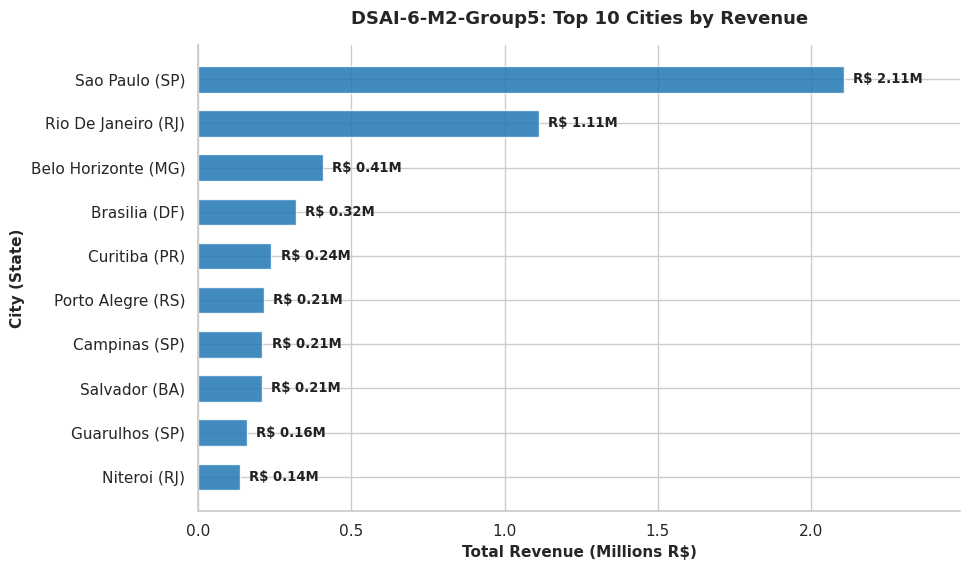

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set visualization theme
sns.set_theme(style='whitegrid', palette='colorblind')

# 2. Load DataFrame from local CSV file
df = pd.read_csv('/home/anton/dsai/Module2_Project/data_mart/mart_revenue_by_location.csv')

# 3. Filter top 10 cities for a clean bar chart layout
top_cities = df.head(10).copy()

# Format city name with state and convert revenue to millions (R$ M)
top_cities['city_label'] = top_cities['city'].str.title() + ' (' + top_cities['state'] + ')'
top_cities['revenue_millions'] = top_cities['total_revenue_Brazilian_Real'] / 1_000_000.0

# 4. Create horizontal bar plot
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(top_cities['city_label'], top_cities['revenue_millions'], color='#1f77b4', alpha=0.85, height=0.6)
ax.invert_yaxis()  # Ranks highest revenue city (São Paulo) at the top

# 5. Format labels and takeaway title
ax.set_title('DSAI-6-M2-Group5: Top 10 Cities by Revenue', 
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Total Revenue (Millions R$)', fontsize=11, fontweight='bold')
ax.set_ylabel('City (State)', fontsize=11, fontweight='bold')

# Add exact value callouts next to each bar
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.03, bar.get_y() + bar.get_height()/2, f'R$ {width:.2f}M', 
            ha='left', va='center', fontsize=9.5, fontweight='bold', color='#222222')

ax.set_xlim(0, max(top_cities['revenue_millions']) * 1.18)
sns.despine()

plt.tight_layout(pad=1.5)
plt.savefig('city_revenue_chart.png', dpi=150, bbox_inches='tight')
plt.show()